In [2]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

In [4]:
import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [5]:
y = np.array(df_y)

print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [7]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [8]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [11]:
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [13]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [14]:
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [18]:
LEARNING_RATE = 0.01

In [23]:
%%timeit -n 1 -r 1
global W, b

losses = []

for i in range(1, 5001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 500 == 0:
        print('Iteration %d : Loss %4f' % (i, L))

Iteration 500 : Loss 3356.957786
Iteration 1000 : Loss 3332.195944
Iteration 1500 : Loss 3309.203790
Iteration 2000 : Loss 3287.800962
Iteration 2500 : Loss 3267.831225
Iteration 3000 : Loss 3249.158790
Iteration 3500 : Loss 3231.665213
Iteration 4000 : Loss 3215.246802
Iteration 4500 : Loss 3199.812430
Iteration 5000 : Loss 3185.281698
735 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [26]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
print("MSE:", mse)

MSE: 2947.5934366712


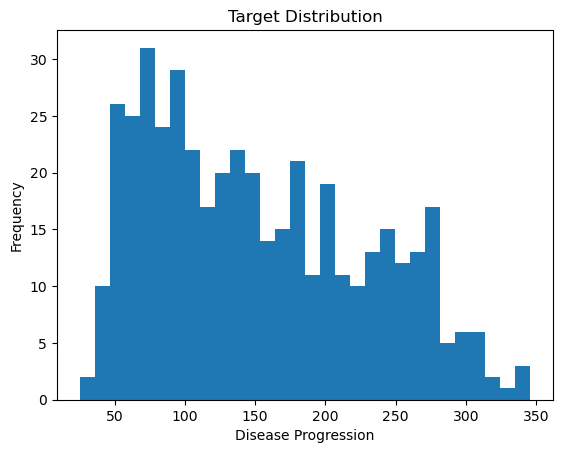

In [30]:
import matplotlib.pyplot as plt

plt.hist(y, bins=30)
plt.title("Target Distribution")
plt.xlabel("Disease Progression")
plt.ylabel("Frequency")
plt.show()